In [20]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.metrics import calculo_radio,calculo_densidad_lex
from src.analysis.pos_analyzer import distribucion_pos

#Se llaman los datos procesados
df = pd.read_csv("../data/processed/resenas_pos_tagged.csv")
df["tokens_spacy"] = df["tokens_spacy"].apply(ast.literal_eval)

df["radio"] = df["tokens_spacy"].apply(calculo_radio)
df["densidad_lexica"] = df["tokens_spacy"].apply(calculo_densidad_lex)

#Se llama la columna con el rating de la resena
calificacion_resena = "calificación"

#Haremos dos DF separados por mejor o peor resena
df_res_pos = df[df[calificacion_resena] > 3].copy()
df_res_neg = df[df[calificacion_resena] < 3].copy()

print(f"Reseñas positivas: {len(df_res_pos)}")
print(f"Reeseñas negativas: {len(df_res_neg)}")


Reseñas positivas: 668
Reeseñas negativas: 74


In [21]:
print(df["tokens_spacy"].iloc[0])

[('fue', 'AUX'), ('una', 'DET'), ('pésima', 'ADJ'), ('experiencia', 'NOUN'), ('llegamos', 'VERB'), ('solo', 'ADV'), ('por', 'ADP'), ('una', 'DET'), ('noche', 'NOUN'), ('porque', 'SCONJ'), ('íbamos', 'AUX'), ('de', 'ADP'), ('paso', 'NOUN'), ('nada', 'NOUN'), ('más', 'ADV'), ('y', 'CCONJ'), ('a', 'ADP'), ('la', 'DET'), ('hora', 'NOUN'), ('de', 'ADP'), ('realizar', 'VERB'), ('el', 'DET'), ('chek', 'NOUN'), ('out', 'PROPN'), ('nos', 'PRON'), ('hicieron', 'VERB'), ('el', 'DET'), ('cobro', 'NOUN'), ('de', 'ADP'), ('una', 'DET'), ('toalla', 'NOUN'), ('que', 'SCONJ'), ('ni', 'CCONJ'), ('siquiera', 'NOUN'), ('pusieron', 'VERB'), ('en', 'ADP'), ('nuestra', 'DET'), ('habitación', 'NOUN'), ('simplemente', 'ADV'), ('fue', 'AUX'), ('inaudito', 'ADJ'), ('pagar', 'VERB'), ('por', 'ADP'), ('algo', 'PRON'), ('que', 'PRON'), ('ellos', 'PRON'), ('ni', 'CCONJ'), ('siquiera', 'NOUN'), ('nos', 'PRON'), ('dieron', 'VERB'), ('pero', 'CCONJ'), ('bueno', 'ADJ'), ('en', 'ADP'), ('fin', 'NOUN'), ('ellos', 'PRON'),

In [23]:
#Calculo de los promedios por reseñas positivas o negativas
print("Resultados en promedios de comparativa entre reseñas positivas y negativas")
print("Radio:")
print(f"Positivas {df_res_pos["radio"].mean():2f}")
print(f"Negativas {df_res_neg["radio"].mean():2f}")

print("Densidad Léxica:")
print(f"Positivas {df_res_pos["densidad_lexica"].mean():2f}")
print(f"Negativas {df_res_neg["densidad_lexica"].mean():2f}")

Resultados en promedios de comparativa entre reseñas positivas y negativas
Radio:
Positivas 2.097290
Negativas 1.490541
Densidad Léxica:
Positivas 0.658323
Negativas 0.586351


Estudios de distribuciones de categorias gramaticales


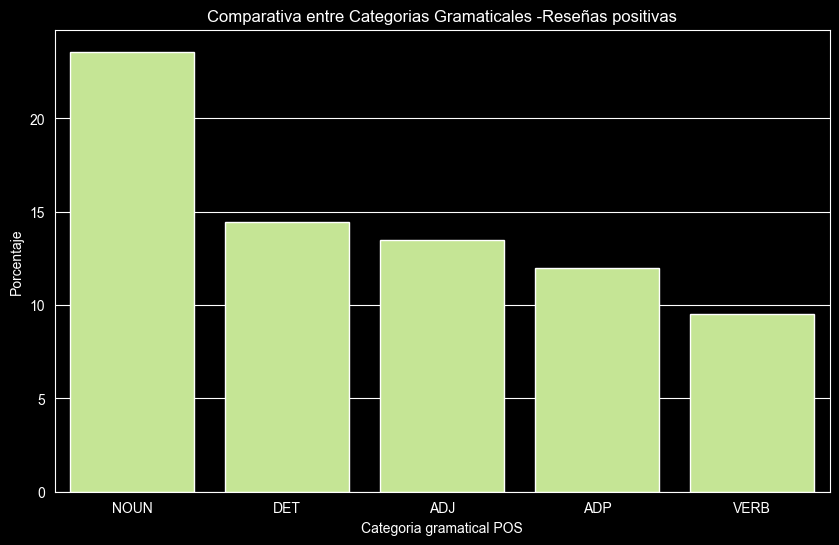

In [34]:
#Comparativas de distribucion de etiquetas

print("Estudios de distribuciones de categorias gramaticales")

distribucion_p = distribucion_pos(df_res_pos["tokens_spacy"])
distribucion_p["Polaridad"] = "Positivas"

distribucion_n = distribucion_pos(df_res_neg["tokens_spacy"])
distribucion_n["Polaridad"] = "Negativas"

#Comparativa mostrada desde un grafico, donde se muestra el top 5
graf = pd.concat([distribucion_p.head(5), distribucion_n.head(5)])
graf.columns

#Positivas
plt.figure(figsize=(10,6))
sns.barplot(data=distribucion_p.head(5), x="Categoría", y="Porcentaje", color="#C8F288")
plt.title("Comparativa entre Categorias Gramaticales -Reseñas positivas")
plt.xlabel("Categoria gramatical POS")
plt.ylabel("Porcentaje")
plt.savefig("../outputs/figures/pos_distribution_positivas.png", bbox_inches='tight')
plt.show()

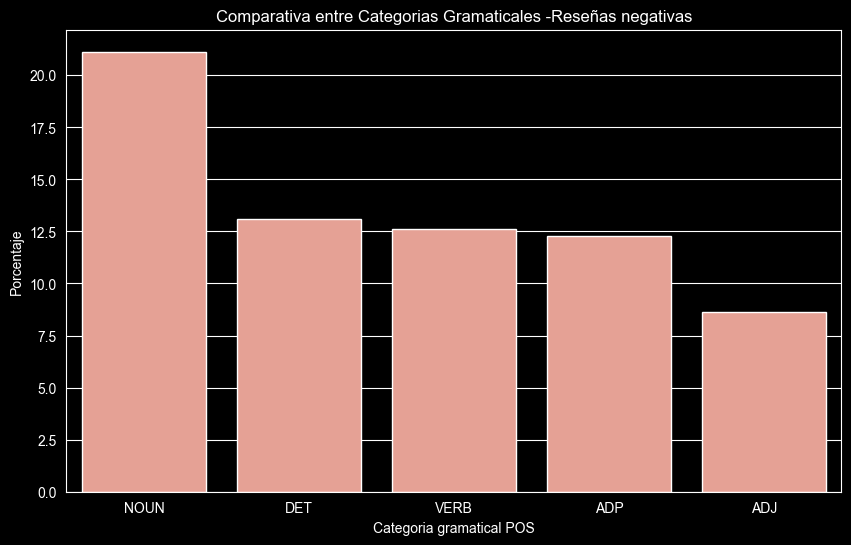

In [33]:
plt.figure(figsize=(10,6))
sns.barplot(data=distribucion_n.head(5), x="Categoría", y="Porcentaje", color="#F29888")
plt.title("Comparativa entre Categorias Gramaticales -Reseñas negativas")
plt.xlabel("Categoria gramatical POS")
plt.ylabel("Porcentaje")
plt.savefig("../outputs/figures/pos_distribution_negativas.png", bbox_inches='tight')
plt.show()